<a href="https://colab.research.google.com/github/muhammadraza2005/Dental-Caries-Segmentation/blob/main/caries_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.5 MB/s eta 0:00:00


In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadrazakhan2005","key":"62aaa2feaec1751ca72bd7d71ad835da"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d muhammadrazakhan2005/adult-caries-detection-dataset

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [6]:
import os

# Manually set the config path just in case
os.environ['KAGGLE_CONFIG_DIR'] = "/root/.kaggle"

# Try the download again with the 'force' flag
!kaggle datasets download -d muhammadrazakhan2005/adult-caries-detection-dataset --force

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariamosamakhalifa/adult-caries-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 887M/887M [00:04<00:00, 201MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mariamosamakhalifa/adult-caries-detection-dataset/versions/1


In [8]:
import shutil
import os

# Define where the data is and where we want it
cache_path = "/root/.cache/kagglehub/datasets/mariamosamakhalifa/adult-caries-detection-dataset/versions/1"
local_path = "/content/dental_data"

# Move the files
if os.path.exists(local_path):
    shutil.rmtree(local_path)
shutil.copytree(cache_path, local_path)

print("Data moved to /content/dental_data")

# List the folders to see the structure
!ls /content/dental_data

Data moved to /content/dental_data
'Adult Dataset Caries Detection'


In [1]:
!ls /content/dental_data

ls: cannot access '/content/dental_data': No such file or directory


In [9]:
import os
import shutil
import random

# 1. Define source directories based on your Kaggle download
source_base = "/content/dental_data/Adult Dataset Caries Detection"
images_dir = os.path.join(source_base, "images")
labels_dir = os.path.join(source_base, "caries_labels")

# 2. Define destination directories for YOLO architecture
dest_base = "/content/dataset"
train_images = os.path.join(dest_base, "images/train")
val_images = os.path.join(dest_base, "images/val")
train_labels = os.path.join(dest_base, "labels/train")
val_labels = os.path.join(dest_base, "labels/val")

# Create the destination folders
for folder in [train_images, val_images, train_labels, val_labels]:
    os.makedirs(folder, exist_ok=True)

# 3. Retrieve all image files and apply a reproducible random shuffle
all_images = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.seed(42)
random.shuffle(all_images)

# 4. Calculate the 80% split index mathematically
split_index = int(len(all_images) * 0.8)
train_files = all_images[:split_index]
val_files = all_images[split_index:]

# 5. Define the function to safely copy image and label pairs
def copy_data(file_list, dest_image_dir, dest_label_dir):
    for image_file in file_list:
        # Copy the image
        src_image_path = os.path.join(images_dir, image_file)
        shutil.copy(src_image_path, os.path.join(dest_image_dir, image_file))

        # Find and copy the corresponding YOLO text label
        label_file = os.path.splitext(image_file)[0] + ".txt"
        src_label_path = os.path.join(labels_dir, label_file)

        if os.path.exists(src_label_path):
            shutil.copy(src_label_path, os.path.join(dest_label_dir, label_file))
        else:
            print(f"Warning: No label found for {image_file}")

# Execute the copy process for both subsets
copy_data(train_files, train_images, train_labels)
copy_data(val_files, val_images, val_labels)

print(f"Dataset successfully split! Training: {len(train_files)} images, Validation: {len(val_files)} images.")

Dataset successfully split! Training: 474 images, Validation: 119 images.


In [10]:
import yaml

# Construct the configuration dictionary
yaml_data = {
    'train': '/content/dataset/images/train',
    'val': '/content/dataset/images/val',
    'nc': 1,
    'names': ['caries']
}

# Write the dictionary to a YAML file format
yaml_path = '/content/dataset/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"data.yaml successfully created at {yaml_path}")

data.yaml successfully created at /content/dataset/data.yaml


In [11]:
from ultralytics import YOLO

# 1. Load the pre-trained Nano model (Fastest and safest for Colab/RTX 3050)
model = YOLO('yolov8n.pt')

# 2. Begin Training
print("Starting the YOLO Spotter training...")
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,                  # 50 rounds of learning. A good baseline test.
    imgsz=640,                  # 640x640 resolution ensures we don't lose tiny cavities
    batch=16,                   # Processes 16 images at a time
    patience=15,                # Early stopping: halts if no improvement for 15 epochs
    project='dental_project',   # Main folder for your results
    name='yolo_spotter_v1'      # Sub-folder for this specific run
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting the YOLO Spotter training...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, h

In [12]:
import os
import cv2

# 1. Define Paths
images_dir = '/content/dataset/images/train'
labels_dir = '/content/dataset/labels/train'

# Create a new directory specifically for U-Net training data
unet_crops_dir = '/content/unet_data/train_crops'
os.makedirs(unet_crops_dir, exist_ok=True)

# 2. Iterate through all training images
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
crop_count = 0

print("Starting Ground Truth Extraction for U-Net...")

for img_name in image_files:
    # Read the image
    img_path = os.path.join(images_dir, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    height, width, _ = img.shape

    # Read the corresponding YOLO label file
    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = os.path.join(labels_dir, label_name)

    if not os.path.exists(label_path):
        continue

    with open(label_path, 'r') as file:
        lines = file.readlines()

    # 3. Convert YOLO format to standard pixel boxes and crop
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) >= 5:
            # YOLO format: class x_center y_center w h (normalized 0 to 1)
            x_center = float(parts[1])
            y_center = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

            # Convert to absolute pixel coordinates
            w_pixels = int(w * width)
            h_pixels = int(h * height)
            x1 = int((x_center * width) - (w_pixels / 2))
            y1 = int((y_center * height) - (h_pixels / 2))
            x2 = x1 + w_pixels
            y2 = y1 + h_pixels

            # Ensure coordinates stay within the image boundaries
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(width, x2), min(height, y2)

            # 4. Slice the image array (Cropping)
            crop = img[y1:y2, x1:x2]

            # Save the cropped ROI
            if crop.size > 0: # Ensure crop is not empty
                crop_filename = f"{os.path.splitext(img_name)[0]}_crop_{idx}.jpg"
                crop_filepath = os.path.join(unet_crops_dir, crop_filename)
                cv2.imwrite(crop_filepath, crop)
                crop_count += 1

print(f"Pipeline Step 1 Complete: Successfully extracted {crop_count} cavity crops for U-Net.")

Starting Ground Truth Extraction for U-Net...
Pipeline Step 1 Complete: Successfully extracted 3568 cavity crops for U-Net.


In [13]:
import cv2
import os
import shutil

# 1. Define paths (Original vs. Enhanced)
base_dataset = '/content/dataset'
enhanced_dataset = '/content/dataset_enhanced'

# Create the new folder structure
folders = ['images/train', 'images/val', 'labels/train', 'labels/val']
for f in folders:
    os.makedirs(os.path.join(enhanced_dataset, f), exist_ok=True)

# 2. Setup the CLAHE algorithm
# clipLimit controls the contrast strength (3.0 is great for X-rays)
# tileGridSize divides the image into an 8x8 grid for local processing
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

def enhance_and_copy(subset):
    img_dir = os.path.join(base_dataset, f'images/{subset}')
    lbl_dir = os.path.join(base_dataset, f'labels/{subset}')

    out_img_dir = os.path.join(enhanced_dataset, f'images/{subset}')
    out_lbl_dir = os.path.join(enhanced_dataset, f'labels/{subset}')

    images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]

    for img_name in images:
        # A. Read image in Grayscale (X-rays don't need color)
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # B. Apply CLAHE contrast filter
        enhanced_img = clahe.apply(img)

        # C. Save enhanced image
        cv2.imwrite(os.path.join(out_img_dir, img_name), enhanced_img)

        # D. Copy the matching label file
        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_name)
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, os.path.join(out_lbl_dir, lbl_name))

print("Applying CLAHE contrast filters...")
enhance_and_copy('train')
enhance_and_copy('val')
print("Enhanced dataset created successfully at /content/dataset_enhanced")

# 3. Create a new data.yaml for the enhanced dataset
import yaml
yaml_data = {
    'train': '/content/dataset_enhanced/images/train',
    'val': '/content/dataset_enhanced/images/val',
    'nc': 1,
    'names': ['caries']
}
with open(os.path.join(enhanced_dataset, 'data_enhanced.yaml'), 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)
print("New data_enhanced.yaml created!")

Applying CLAHE contrast filters...
Enhanced dataset created successfully at /content/dataset_enhanced
New data_enhanced.yaml created!


In [14]:
from ultralytics import YOLO

# 1. Load the pre-trained Nano model again
model = YOLO('yolov8n.pt')

# 2. Begin Optimized Training
print("Starting YOLO Training on Enhanced Medical Data...")
results = model.train(
    data='/content/dataset_enhanced/data_enhanced.yaml', # Pointing to the new CLAHE data
    epochs=150,                 # Tripled the learning time
    imgsz=640,
    batch=16,
    patience=30,                # Give it 30 epochs of grace period before early stopping
    augment=True,               # Force YOLO to rotate and flip images to learn harder
    project='dental_project',
    name='yolo_spotter_clahe_v2' # New folder so we don't overwrite V1
)

Starting YOLO Training on Enhanced Medical Data...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_enhanced/data_enhanced.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_spotter_clahe_v2, nbs=64, nms=F

In [15]:
import cv2
import os
import numpy as np

# 1. Define Paths
crop_dir = '/content/unet_data/train_crops'
mask_dir = '/content/unet_data/train_masks'
os.makedirs(mask_dir, exist_ok=True)

print("Starting automated binary mask generation...")

crop_files = [f for f in os.listdir(crop_dir) if f.endswith('.jpg')]
success_count = 0

for file in crop_files:
    img_path = os.path.join(crop_dir, file)

    # Read the crop in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # 2. Invert the image (so the dark cavity becomes bright white)
    inverted_img = cv2.bitwise_not(img)

    # 3. Apply a Gaussian blur to smooth out the grainy X-ray noise
    blurred = cv2.GaussianBlur(inverted_img, (5, 5), 0)

    # 4. Otsu's Thresholding: Automatically finds the dividing line between "cavity" and "tooth"
    _, binary_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Save the generated mask
    mask_filename = file.replace('.jpg', '_mask.png')
    cv2.imwrite(os.path.join(mask_dir, mask_filename), binary_mask)
    success_count += 1

print(f"Mask Generation Complete! Successfully generated {success_count} masks.")

Starting automated binary mask generation...
Mask Generation Complete! Successfully generated 3568 masks.


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_unet_surgeon(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    # -----------------------------------------
    # 1. ENCODER (Contracting Path)
    # -----------------------------------------
    # Level 1: Catching the fine edges of the enamel
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Level 2: Finding the darker shadows
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Level 3 (Bottleneck): The deepest understanding of "Decay vs Healthy"
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)

    # -----------------------------------------
    # 2. DECODER (Expanding Path with Skip Connections)
    # -----------------------------------------
    # Level 4: Upsampling and grabbing high-res details from Level 2
    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2]) # <--- This is the Skip Connection!
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c4)

    # Level 5: Upsampling and grabbing fine edges from Level 1
    u5 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1]) # <--- Skip Connection!
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c5)

    # -----------------------------------------
    # 3. OUTPUT LAYER
    # -----------------------------------------
    # A single filter with a Sigmoid activation.
    # Sigmoid forces every pixel to output a value between 0 (Black) and 1 (White).
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs], name="Dental_UNet_Surgeon")
    return model

# Instantiate the model. We use 128x128 resolution and 1 channel (Grayscale)
unet_model = build_unet_surgeon(input_shape=(128, 128, 1))
unet_model.summary()

Model: "Dental_UNet_Surgeon"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │     32,832 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 128, 128,  │      8,224 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_8[0][0]  

 Total params: 465,953 (1.78 MB)

 Trainable params: 465,953 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

# 1. UPDATED: Bulletproof Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    # Explicitly cast both inputs to float32 so TensorFlow math doesn't crash
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# 2. Data Loading Engine
crop_dir = '/content/unet_data/train_crops'
mask_dir = '/content/unet_data/train_masks'

print("Loading 3568 images into RAM for fast training... Please wait.")
X_data = []
Y_data = []

crop_files = sorted([f for f in os.listdir(crop_dir) if f.endswith('.jpg')])

for file in crop_files:
    crop_path = os.path.join(crop_dir, file)
    img = cv2.imread(crop_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128, 128))
    X_data.append(img / 255.0)

    mask_filename = file.replace('.jpg', '_mask.png')
    mask_path = os.path.join(mask_dir, mask_filename)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (128, 128))
    _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
    Y_data.append(mask)

# UPDATED: Force the numpy arrays to be float32 from the start
X_train = np.array(X_data, dtype=np.float32).reshape(-1, 128, 128, 1)
Y_train = np.array(Y_data, dtype=np.float32).reshape(-1, 128, 128, 1)
print(f"Data Loaded! X shape: {X_train.shape}, Y shape: {Y_train.shape}")

# 3. Compile the Brain
print("Compiling the U-Net Surgeon...")
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef]
)

# 4. Begin Training
print("Starting Training...")
history = unet_model.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=40
)

# 5. Save the finished model
unet_model.save('/content/dental_unet_surgeon.h5')
print("Training Complete! Model saved as dental_unet_surgeon.h5")

Loading 3568 images into RAM for fast training... Please wait.
Data Loaded! X shape: (3568, 128, 128, 1), Y shape: (3568, 128, 128, 1)
Compiling the U-Net Surgeon...
Starting Training...
Epoch 1/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 48s 326ms/step - accuracy: 0.5917 - dice_coef: 0.5451 - loss: 0.6662 - val_accuracy: 0.6290 - val_dice_coef: 0.5532 - val_loss: 0.6416
Epoch 2/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6280 - dice_coef: 0.5731 - loss: 0.6433 - val_accuracy: 0.6351 - val_dice_coef: 0.5780 - val_loss: 0.6370
Epoch 3/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.6338 - dice_coef: 0.5766 - loss: 0.6394 - val_accuracy: 0.6335 - val_dice_coef: 0.5771 - val_loss: 0.6372
Epoch 4/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6361 - dice_coef: 0.5808 - loss: 0.6366 - val_accuracy: 0.6322 - val_dice_coef: 0.5759 - val_loss: 0.6374
Epoch 5/40
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.6340 - dice_coef: 0.5793 - loss: 0.6368 - val_accuracy

Training Complete! Model saved as dental_unet_surgeon.h5


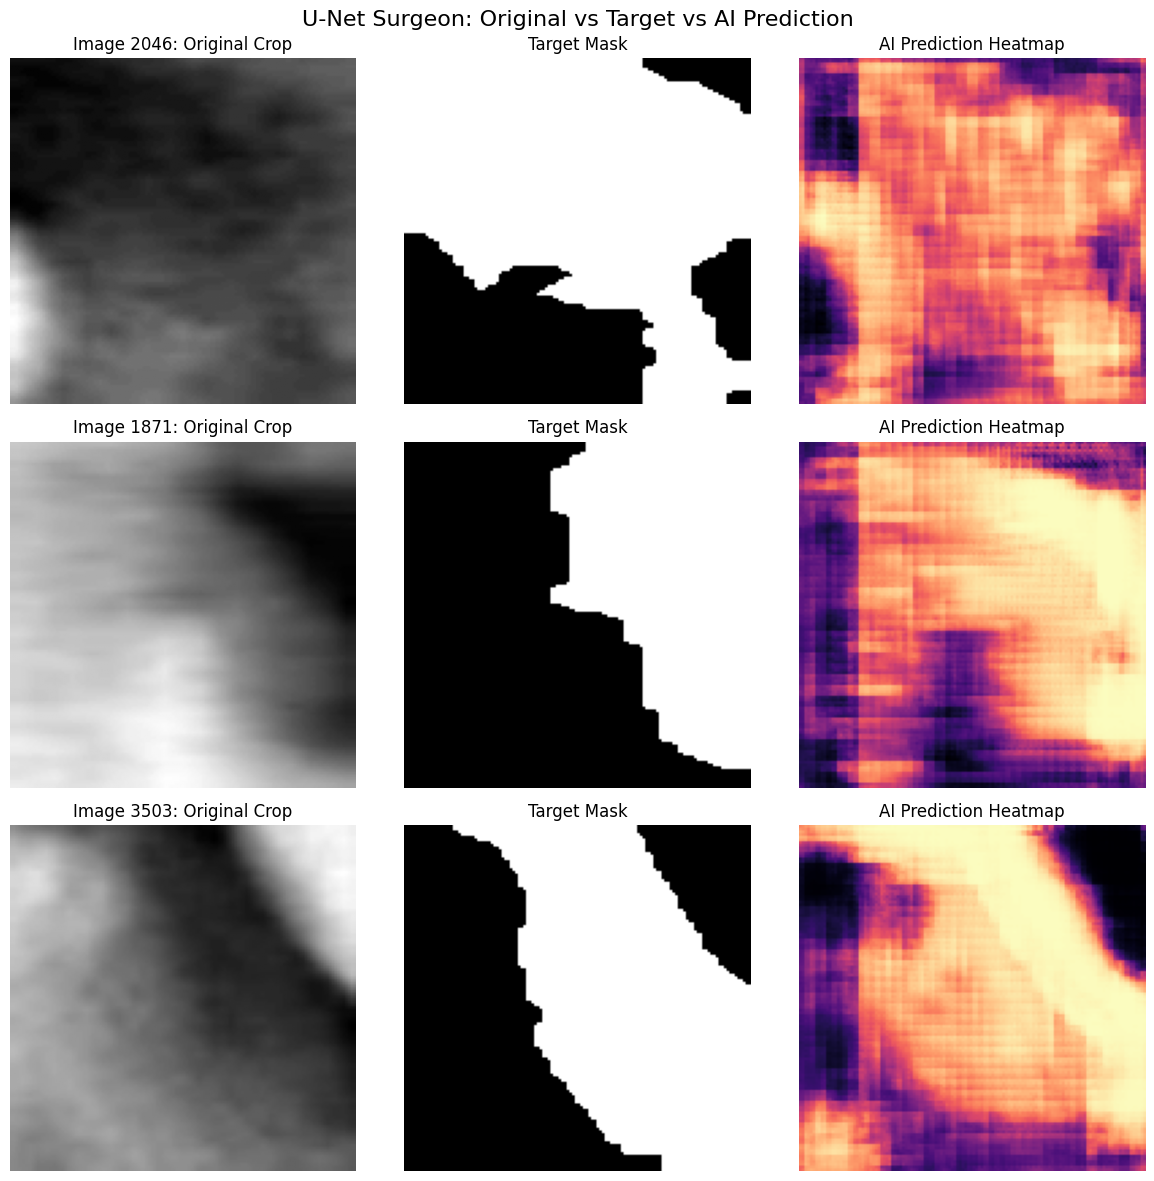

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Select 3 random indices from your loaded data
num_samples = 3
indices = np.random.randint(0, len(X_train), num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
plt.suptitle("U-Net Surgeon: Original vs Target vs AI Prediction", fontsize=16)

for i, idx in enumerate(indices):
    # 1. Grab the single test image (keeping the required 4D shape)
    test_img = X_train[idx:idx+1]
    true_mask = Y_train[idx]

    # 2. Ask the U-Net to predict where the cavity is
    ai_prediction = unet_model.predict(test_img, verbose=0)[0]

    # 3. Plot Original X-Ray Crop
    axes[i, 0].imshow(test_img[0, :, :, 0], cmap='gray')
    axes[i, 0].set_title(f"Image {idx}: Original Crop")
    axes[i, 0].axis('off')

    # 4. Plot Ground Truth (Otsu Target)
    axes[i, 1].imshow(true_mask[:, :, 0], cmap='gray')
    axes[i, 1].set_title("Target Mask")
    axes[i, 1].axis('off')

    # 5. Plot AI Prediction (Using a heatmap to show confidence)
    im = axes[i, 2].imshow(ai_prediction[:, :, 0], cmap='magma')
    axes[i, 2].set_title("AI Prediction Heatmap")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()